# Homework 3 — Machine Learning for Classification

ML Zoomcamp 2026 · Module 3

Assignment: [cohorts/2026/homework/03-classification](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/cohorts/2026/homework/03-classification/homework.md)

Goal: predict whether a lead signs up (`converted`) with logistic regression on the 2026 lead-scoring dataset.

Due: **5 Oct 2026, 23:00 UTC**

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score, accuracy_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline

---
## Getting the data

In [2]:
!mkdir -p data && curl -sSL -o data/course_lead_scoring_2026.csv \
    https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv

In [3]:
df = pd.read_csv('data/course_lead_scoring_2026.csv')
print(df.shape)
df.head()

(5000, 9)


,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


---
## Data preparation

* Check for missing values.
* Categorical features → `'NA'`; numerical features → `0.0`.

In [4]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [5]:
categorical = list(df.select_dtypes(include='object').columns)
numerical = [c for c in df.columns if c not in categorical + ['converted']]
print(categorical)
print(numerical)

df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)
df.isnull().sum().sum()

['lead_source', 'industry', 'employment_status', 'location']
['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']


/var/folders/kb/bct8x8yj5512r8bk3qkjytbc0000gq/T/ipykernel_47496/3714788266.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = list(df.select_dtypes(include='object').columns)


np.int64(0)

---
## Q1. Mode of `industry`

*Options: `NA` / `technology` / `healthcare` / `retail`*

In [6]:
# Q1
df.industry.value_counts()

industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64

---
## Q2. Correlation matrix

Which pair has the biggest correlation? Only the four pairs in the options count.

*Options: `interaction_count` & `lead_score` / `number_of_courses_viewed` & `lead_score` / `number_of_courses_viewed` & `interaction_count` / `annual_income` & `interaction_count`*

,annual_income,number_of_courses_viewed,interaction_count,lead_score
annual_income,1.0000,0.1613,0.1228,0.2295
number_of_courses_viewed,0.1613,1.0000,0.7216,0.7572
interaction_count,0.1228,0.7216,1.0000,0.9157
lead_score,0.2295,0.7572,0.9157,1.0000


<Axes: >

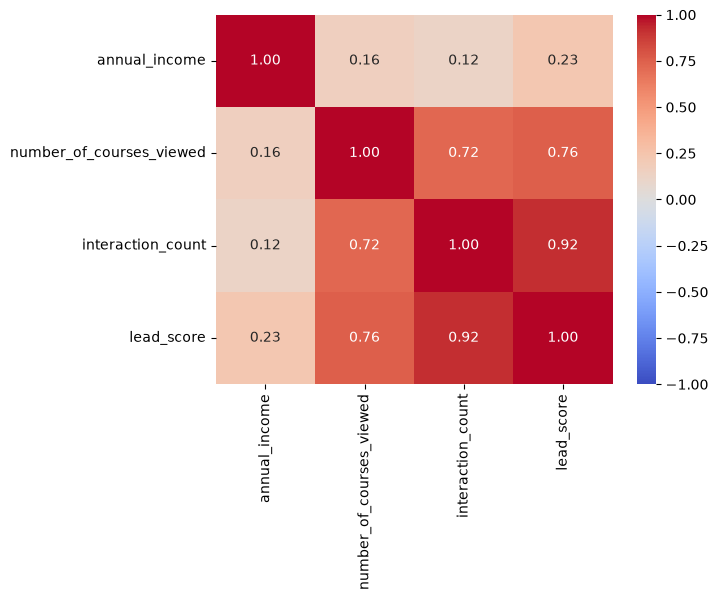

In [7]:
# Q2
corr = df[numerical].corr()
display(corr.round(4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

In [8]:
pairs = [
    ('interaction_count', 'lead_score'),
    ('number_of_courses_viewed', 'lead_score'),
    ('number_of_courses_viewed', 'interaction_count'),
    ('annual_income', 'interaction_count'),
]
for a, b in pairs:
    print(f"{a} & {b}: {corr.loc[a, b]:.4f}")

interaction_count & lead_score: 0.9157
number_of_courses_viewed & lead_score: 0.7572
number_of_courses_viewed & interaction_count: 0.7216
annual_income & interaction_count: 0.1228


---
## Split the data

Exact calls from the assignment (60 / 20 / 20), then remove the target from the feature frames.

In [9]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

len(df_train), len(df_val), len(df_test)

(3000, 1000, 1000)

---
## Q3. Mutual information

Categorical variables vs `converted`, training set only, `round(score, 2)`.

*Options: `industry` / `location` / `lead_source` / `employment_status`*

In [10]:
# Q3
mi = {c: mutual_info_score(df_train[c], y_train) for c in categorical}
for c, s in sorted(mi.items(), key=lambda x: -x[1]):
    print(f"{c:<20} {round(s, 2)}   (raw {s:.4f})")

lead_source          0.03   (raw 0.0343)
employment_status    0.02   (raw 0.0190)
industry             0.0   (raw 0.0020)
location             0.0   (raw 0.0010)


---
## Q4. Logistic regression

One-hot encode the categorical features, fit on train, accuracy on validation (2 decimals).

*Options: 0.55 / 0.65 / 0.75 / 0.85*

In [11]:
def train_and_score(features, C=1.0):
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(df_train[features].to_dict(orient='records'))
    X_val = dv.transform(df_val[features].to_dict(orient='records'))

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return accuracy_score(y_val, model.predict(X_val))

In [12]:
# Q4
features = categorical + numerical
base_acc = train_and_score(features)
print(f"accuracy = {base_acc:.4f} -> {round(base_acc, 2)}")

accuracy = 0.6450 -> 0.65


---
## Q5. Feature elimination

Drop each feature in turn; difference = original accuracy − accuracy without it.

*Options: `lead_source` / `number_of_courses_viewed` / `interaction_count`*

In [13]:
# Q5
diffs = {}
for f in features:
    acc = train_and_score([x for x in features if x != f])
    diffs[f] = base_acc - acc

pd.Series(diffs, name='difference').sort_values().to_frame()

,difference
annual_income,-0.079
industry,0.000
employment_status,0.000
location,0.000
lead_score,0.001
number_of_courses_viewed,0.002
lead_source,0.003
interaction_count,0.044


In [14]:
candidates = ['lead_source', 'number_of_courses_viewed', 'interaction_count']
{f: round(diffs[f], 4) for f in candidates}

{'lead_source': 0.003,
 'number_of_courses_viewed': 0.002,
 'interaction_count': 0.044}

---
## Q6. Regularization

`C` in `[0.000001, 0.00001, 0.0001, 0.001]`, accuracy with `round(score, 3)`; ties → smallest `C`.

*Options: 0.000001 / 0.00001 / 0.0001 / 0.001*

In [15]:
# Q6
for C in [0.000001, 0.00001, 0.0001, 0.001]:
    print(f"C={C:<9} accuracy = {round(train_and_score(features, C=C), 3)}")

C=1e-06     accuracy = 0.598
C=1e-05     accuracy = 0.598
C=0.0001    accuracy = 0.613
C=0.001     accuracy = 0.645


---
## Answers

| Question | Answer | Computed value |
|---|---|---|
| Q1 — mode of `industry` | **`technology`** | 1173 rows (`NA` only 240) |
| Q2 — biggest correlation | **`interaction_count` and `lead_score`** | 0.9157 |
| Q3 — highest mutual information | **`lead_source`** | 0.03 |
| Q4 — validation accuracy | **0.65** | 0.6450 |
| Q5 — smallest difference | **`number_of_courses_viewed`** | 0.002 (vs 0.003 `lead_source`, 0.044 `interaction_count`) |
| Q6 — best `C` | **0.001** | 0.645; smaller `C` underfits (0.598 – 0.613) |

Notes:

- `annual_income` has a *negative* difference (−0.079): removing it **raises** accuracy, because unscaled income (~tens of thousands) dominates the other features. Scaling would likely fix that — see `notebook-scaling-ohe.ipynb` in the course repo.
- Q6: with strong regularization the model collapses toward the majority class; accuracy only recovers once `C` grows.

**Reflection** (asked on the submission form): *Describe one practical idea you took from this module.*

>